In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
print("Packages installed successfully!")

#source env/bin/activate

Packages installed successfully!


In [2]:
#run this if doesn work in terminal
#pip install pandas numpy matplotlib seaborn scikit-learn
#Load the dataset
data = pd.read_csv('data/india_city_aqi.csv')


In [3]:
# Display the first few rows
print(data.head())

       City    State  Latitude  Longitude             Datetime  Year  Month  \
0  Agartala  Tripura   23.8315    91.2868  2022-08-05 00:00:00  2022      8   
1  Agartala  Tripura   23.8315    91.2868  2022-08-05 01:00:00  2022      8   
2  Agartala  Tripura   23.8315    91.2868  2022-08-05 02:00:00  2022      8   
3  Agartala  Tripura   23.8315    91.2868  2022-08-05 03:00:00  2022      8   
4  Agartala  Tripura   23.8315    91.2868  2022-08-05 04:00:00  2022      8   

   Day  Hour  Day_of_Week  ... US_AQI_CO  EU_AQI  EU_AQI_PM25  EU_AQI_PM10  \
0    5     0            4  ...         2     NaN          NaN          NaN   
1    5     1            4  ...         2     NaN          NaN          NaN   
2    5     2            4  ...         2     NaN          NaN          NaN   
3    5     3            4  ...         2     NaN          NaN          NaN   
4    5     4            4  ...         2     NaN          NaN          NaN   

  AQI_Category PM25_Category_India  Temp_Inversion  Inve

In [4]:
# Display basic information about the dataset
print(data.info())


<class 'pandas.DataFrame'>
RangeIndex: 842160 entries, 0 to 842159
Data columns (total 71 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   City                   842160 non-null  str    
 1   State                  842160 non-null  str    
 2   Latitude               842160 non-null  float64
 3   Longitude              842160 non-null  float64
 4   Datetime               842160 non-null  str    
 5   Year                   842160 non-null  int64  
 6   Month                  842160 non-null  int64  
 7   Day                    842160 non-null  int64  
 8   Hour                   842160 non-null  int64  
 9   Day_of_Week            842160 non-null  int64  
 10  Day_Name               842160 non-null  str    
 11  Week_of_Year           842160 non-null  int64  
 12  Is_Weekend             842160 non-null  int64  
 13  Quarter                842160 non-null  int64  
 14  Season                 842160 non-null  str    

In [5]:
# Check for missing values
print(data.isnull().sum())

City                         0
State                        0
Latitude                     0
Longitude                    0
Datetime                     0
                         ...  
PM25_Category_India          2
Temp_Inversion               0
Inversion_Strength_C    842160
Festival_Period              0
Crop_Burning_Season          0
Length: 71, dtype: int64


In [6]:
# Summary statistics
print(data.describe())

            Latitude      Longitude           Year          Month  \
count  842160.000000  842160.000000  842160.000000  842160.000000   
mean       23.129041      82.769207    2023.724793       6.801653   
std         5.543478       6.937205       0.995593       3.411504   
min         8.524100      72.571400    2022.000000       1.000000   
25%        20.296100      77.173400    2023.000000       4.000000   
50%        23.831500      80.946200    2024.000000       7.000000   
75%        26.912400      88.606500    2025.000000      10.000000   
max        31.104800      94.108600    2025.000000      12.000000   

                 Day           Hour    Day_of_Week   Week_of_Year  \
count  842160.000000  842160.000000  842160.000000  842160.000000   
mean       15.736364      11.500000       3.000000      27.767769   
std         8.767003       6.922191       2.000827      14.848660   
min         1.000000       0.000000       0.000000       1.000000   
25%         8.000000       5.7500

In [7]:
# Summary statistics
print(data.describe())

            Latitude      Longitude           Year          Month  \
count  842160.000000  842160.000000  842160.000000  842160.000000   
mean       23.129041      82.769207    2023.724793       6.801653   
std         5.543478       6.937205       0.995593       3.411504   
min         8.524100      72.571400    2022.000000       1.000000   
25%        20.296100      77.173400    2023.000000       4.000000   
50%        23.831500      80.946200    2024.000000       7.000000   
75%        26.912400      88.606500    2025.000000      10.000000   
max        31.104800      94.108600    2025.000000      12.000000   

                 Day           Hour    Day_of_Week   Week_of_Year  \
count  842160.000000  842160.000000  842160.000000  842160.000000   
mean       15.736364      11.500000       3.000000      27.767769   
std         8.767003       6.922191       2.000827      14.848660   
min         1.000000       0.000000       0.000000       1.000000   
25%         8.000000       5.7500

In [8]:
numeric_cols = data.select_dtypes(include='number').columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

# Verify that there are no missing values left in numeric columns
print(data[numeric_cols].isnull().sum())

Latitude                     0
Longitude                    0
Year                         0
Month                        0
Day                          0
                         ...  
EU_AQI_PM10                  0
Temp_Inversion               0
Inversion_Strength_C    842160
Festival_Period              0
Crop_Burning_Season          0
Length: 61, dtype: int64


In [9]:
# Remove duplicates
data.drop_duplicates(inplace=True)

In [10]:
# Print column names to verify the existence of 'date'
print(data.columns)

Index(['City', 'State', 'Latitude', 'Longitude', 'Datetime', 'Year', 'Month',
       'Day', 'Hour', 'Day_of_Week', 'Day_Name', 'Week_of_Year', 'Is_Weekend',
       'Quarter', 'Season', 'Time_of_Day', 'Temp_2m_C', 'Temp_80m_C',
       'Temp_120m_C', 'Temp_180m_C', 'Humidity_Percent', 'Dew_Point_C',
       'Humidity_Category', 'Wind_Speed_10m_kmh', 'Wind_Speed_80m_kmh',
       'Wind_Speed_120m_kmh', 'Wind_Dir_10m', 'Wind_Gusts_kmh',
       'Wind_Category', 'Wind_Stagnation', 'Precipitation_mm', 'Rain_mm',
       'Is_Raining', 'Heavy_Rain', 'Pressure_MSL_hPa', 'Surface_Pressure_hPa',
       'Solar_Radiation_Wm2', 'Direct_Radiation_Wm2', 'Diffuse_Radiation_Wm2',
       'UV_Index', 'Cloud_Cover_Percent', 'Cloud_Low_Percent',
       'Cloud_Mid_Percent', 'Cloud_High_Percent', 'Is_Daytime',
       'Sunshine_Seconds', 'PM2_5_ugm3', 'PM10_ugm3', 'PM_Ratio', 'CO_ugm3',
       'NO2_ugm3', 'SO2_ugm3', 'O3_ugm3', 'Dust_ugm3', 'NH3_ugm3', 'AOD',
       'US_AQI', 'US_AQI_PM25', 'US_AQI_PM10', 'US_AQI_

In [11]:
# Convert data types if necessary (update based on your dataset)
if 'date' in data.columns:
    data['date'] = pd.to_datetime(data['date'])
elif 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'])
else:
    print("Date column not found in the dataset")

# Display the first few rows to verify changes
print(data.head())

Date column not found in the dataset
       City    State  Latitude  Longitude             Datetime  Year  Month  \
0  Agartala  Tripura   23.8315    91.2868  2022-08-05 00:00:00  2022      8   
1  Agartala  Tripura   23.8315    91.2868  2022-08-05 01:00:00  2022      8   
2  Agartala  Tripura   23.8315    91.2868  2022-08-05 02:00:00  2022      8   
3  Agartala  Tripura   23.8315    91.2868  2022-08-05 03:00:00  2022      8   
4  Agartala  Tripura   23.8315    91.2868  2022-08-05 04:00:00  2022      8   

   Day  Hour  Day_of_Week  ... US_AQI_CO     EU_AQI  EU_AQI_PM25  EU_AQI_PM10  \
0    5     0            4  ...         2  62.815243    58.034527    48.424171   
1    5     1            4  ...         2  62.815243    58.034527    48.424171   
2    5     2            4  ...         2  62.815243    58.034527    48.424171   
3    5     3            4  ...         2  62.815243    58.034527    48.424171   
4    5     4            4  ...         2  62.815243    58.034527    48.424171   

 

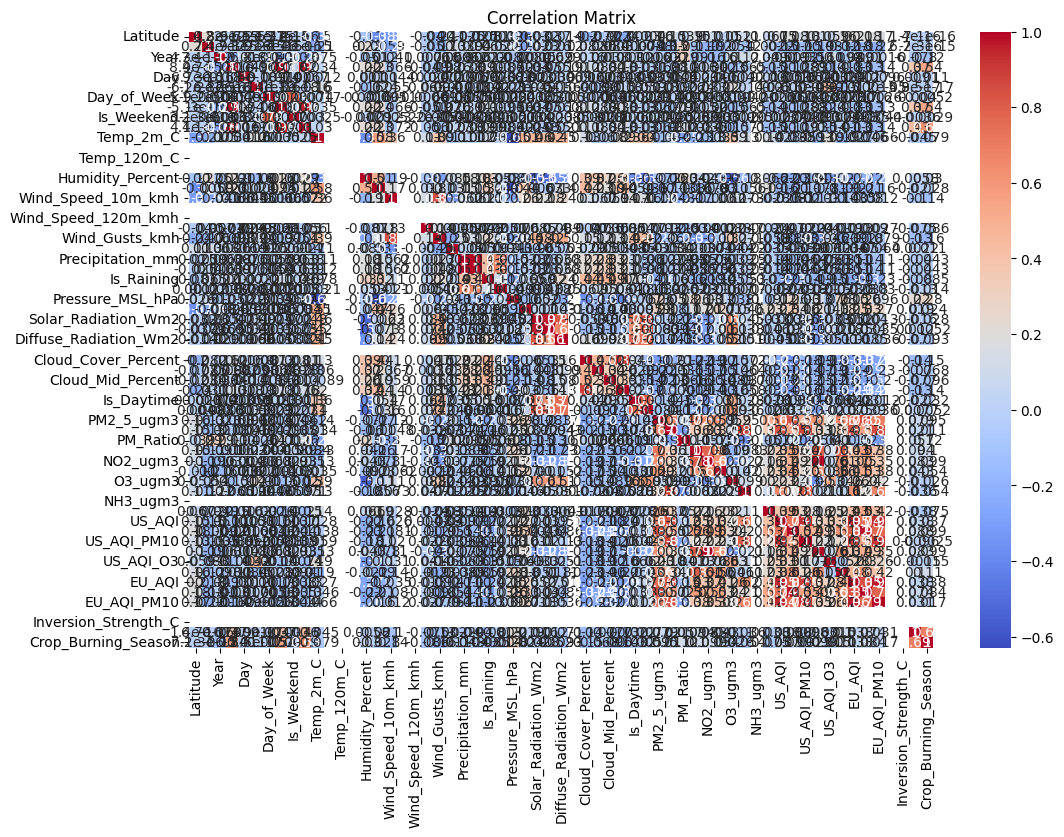

In [12]:
# Select only numeric columns for the correlation matrix
numeric_data = data.select_dtypes(include='number')

# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Explanation of the Correlation Matrix

A correlation matrix is a table showing correlation coefficients between many variables. Each cell in the table shows the correlation between two variables. The value is in the range of -1 to 1.

1 indicates a perfect positive correlation.
-1 indicates a perfect negative correlation.
0 indicates no correlation.

### Result heatmap:

Diagonal Values: These are all 1.0 because a variable is always perfectly correlated with itself.
Off-Diagonal Values: These show the pairwise correlations between different variables.

### Interpretation of the Heatmap

1.	Strong Positive Correlations (close to 1):
	aqi_value and pm2.5_aqi_value (0.98): This strong positive correlation indicates that as pm2.5_aqi_value increases, the aqi_value also increases significantly. PM2.5 (particulate matter with diameter less than 2.5 micrometers) is a major component of air pollution and heavily influences the Air Quality Index (AQI).co_aqi_value and no2_aqi_value (0.49): Carbon monoxide and nitrogen dioxide show a moderate positive correlation, suggesting they often increase or decrease together.

2.	Moderate Positive Correlations (0.3 to 0.5):
	co_aqi_value and pm2.5_aqi_value (0.44): This suggests that there is a moderate relationship between carbon monoxide and PM2.5 levels.
	ozone_aqi_value and co_aqi_value (0.15): Although lower, there is still a noticeable correlation indicating these pollutants can sometimes increase or decrease together.

3.	Weak or Negative Correlations (close to 0 or negative)
	no2_aqi_value and ozone_aqi_value (-0.18): A negative correlation here suggests that these two pollutants might often be inversely related; when one is high, the other might be low.

### Insights

1. Impact on AQI: The pm2.5_aqi_value has the highest impact on the overall aqi_value, indicating it is the primary pollutant driving the AQI values in your dataset.
2. Pairwise Relations: The positive correlation between co_aqi_value and no2_aqi_value suggests that these pollutants often come from similar sources or conditions, such as traffic emissions.
3. Inverse Relationships: The negative correlation between ozone_aqi_value and no2_aqi_value can be indicative of complex chemical interactions in the atmosphere where the presence of one can reduce the other.


## PM2.5 Analysis

In [13]:
import pandas as pd
import streamlit as st

# Load the dataset
data = pd.read_csv("data/india_city_aqi.csv")


###  Analyzing the seasonal trends and daily patterns of PM2.5 concentrations.

#### Time Series Decomposition

break down the time series data into its seasonal, trend, and residual components.

#### Display the first few rows of the dataset

In [14]:
print("First few rows of the dataset:")
display(data.head())

First few rows of the dataset:


,City,State,Latitude,Longitude,Datetime,Year,Month,Day,Hour,Day_of_Week,...,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,AQI_Category,PM25_Category_India,Temp_Inversion,Inversion_Strength_C,Festival_Period,Crop_Burning_Season
0,Agartala,Tripura,23.8315,91.2868,2022-08-05 00:00:00,2022,8,5,0,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
1,Agartala,Tripura,23.8315,91.2868,2022-08-05 01:00:00,2022,8,5,1,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
2,Agartala,Tripura,23.8315,91.2868,2022-08-05 02:00:00,2022,8,5,2,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
3,Agartala,Tripura,23.8315,91.2868,2022-08-05 03:00:00,2022,8,5,3,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
4,Agartala,Tripura,23.8315,91.2868,2022-08-05 04:00:00,2022,8,5,4,4,...,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0


#### Display the column names to inspect what is available

In [15]:
print("Column names in the dataset:")
print(data.columns)


Column names in the dataset:
Index(['City', 'State', 'Latitude', 'Longitude', 'Datetime', 'Year', 'Month',
       'Day', 'Hour', 'Day_of_Week', 'Day_Name', 'Week_of_Year', 'Is_Weekend',
       'Quarter', 'Season', 'Time_of_Day', 'Temp_2m_C', 'Temp_80m_C',
       'Temp_120m_C', 'Temp_180m_C', 'Humidity_Percent', 'Dew_Point_C',
       'Humidity_Category', 'Wind_Speed_10m_kmh', 'Wind_Speed_80m_kmh',
       'Wind_Speed_120m_kmh', 'Wind_Dir_10m', 'Wind_Gusts_kmh',
       'Wind_Category', 'Wind_Stagnation', 'Precipitation_mm', 'Rain_mm',
       'Is_Raining', 'Heavy_Rain', 'Pressure_MSL_hPa', 'Surface_Pressure_hPa',
       'Solar_Radiation_Wm2', 'Direct_Radiation_Wm2', 'Diffuse_Radiation_Wm2',
       'UV_Index', 'Cloud_Cover_Percent', 'Cloud_Low_Percent',
       'Cloud_Mid_Percent', 'Cloud_High_Percent', 'Is_Daytime',
       'Sunshine_Seconds', 'PM2_5_ugm3', 'PM10_ugm3', 'PM_Ratio', 'CO_ugm3',
       'NO2_ugm3', 'SO2_ugm3', 'O3_ugm3', 'Dust_ugm3', 'NH3_ugm3', 'AOD',
       'US_AQI', 'US_AQI_P

#### Handle missing values

In [16]:
numeric_cols = data.select_dtypes(include='number').columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

#### Select a country for filtering (for example, 'Indonesia')

In [17]:
selected_city = "Delhi"

filtered_data = data[data["City"] == selected_city]

print(f"Air Quality Data for {selected_city}:")
display(filtered_data.head())

Air Quality Data for Delhi:


,City,State,Latitude,Longitude,Datetime,Year,Month,Day,Hour,Day_of_Week,...,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,AQI_Category,PM25_Category_India,Temp_Inversion,Inversion_Strength_C,Festival_Period,Crop_Burning_Season
261360,Delhi,Delhi,28.6139,77.209,2022-08-05 00:00:00,2022,8,5,0,4,...,8,62.815243,58.034527,48.424171,NaN,Satisfactory,0,NaN,0,0
261361,Delhi,Delhi,28.6139,77.209,2022-08-05 01:00:00,2022,8,5,1,4,...,8,62.815243,58.034527,48.424171,NaN,Satisfactory,0,NaN,0,0
261362,Delhi,Delhi,28.6139,77.209,2022-08-05 02:00:00,2022,8,5,2,4,...,8,62.815243,58.034527,48.424171,NaN,Good,0,NaN,0,0
261363,Delhi,Delhi,28.6139,77.209,2022-08-05 03:00:00,2022,8,5,3,4,...,8,62.815243,58.034527,48.424171,NaN,Good,0,NaN,0,0
261364,Delhi,Delhi,28.6139,77.209,2022-08-05 04:00:00,2022,8,5,4,4,...,7,62.815243,58.034527,48.424171,NaN,Good,0,NaN,0,0


#### Check for missing values in 'pm2.5_aqi_value'

In [18]:
if filtered_data["PM2_5_ugm3"].isnull().sum() > 0:
    print("Warning: Missing values found in 'PM2_5_ugm3'. These will be dropped.")
    filtered_data = filtered_data.dropna(subset=["PM2_5_ugm3"])

### Distribution of PM2.5 AQI Value

Distribution of PM2.5 Concentration


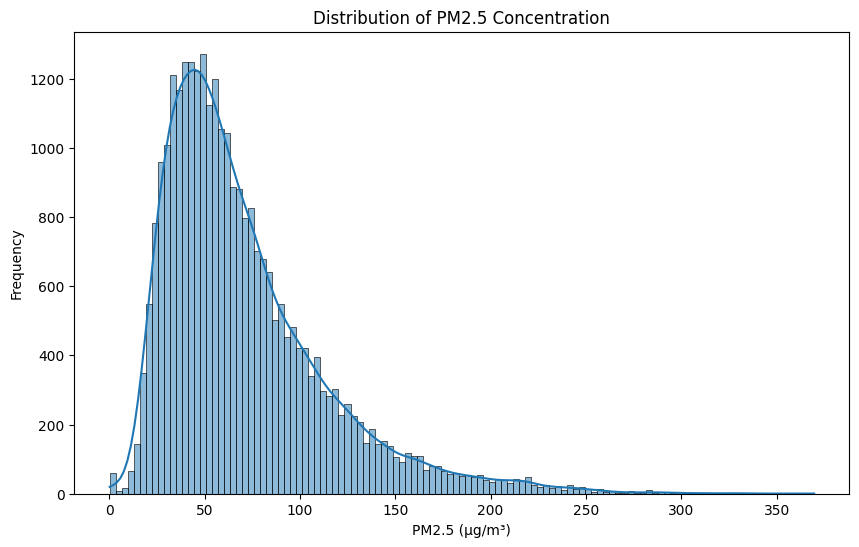

In [19]:
print("Distribution of PM2.5 Concentration")

plt.figure(figsize=(10, 6))

sns.histplot(filtered_data["PM2_5_ugm3"], kde=True)

plt.title("Distribution of PM2.5 Concentration")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency")

plt.show()

### PM2.5 vs AQI

PM2.5 vs AQI


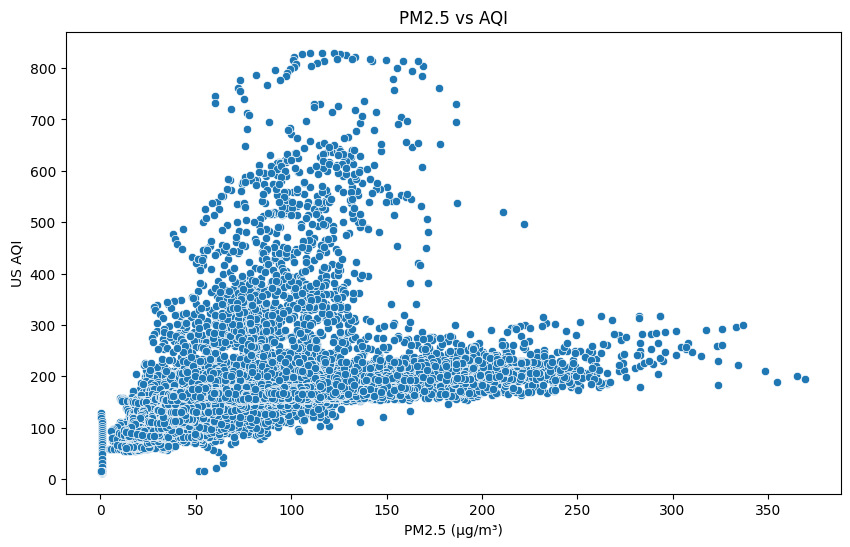

In [20]:
print("PM2.5 vs AQI")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=filtered_data["PM2_5_ugm3"],
    y=filtered_data["US_AQI"]
)

plt.title("PM2.5 vs AQI")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("US AQI")

plt.show()

### Correlation between PM2.5 and AQI

In [21]:
correlation = filtered_data["PM2_5_ugm3"].corr(filtered_data["US_AQI"])

print(f"Correlation between PM2.5 and AQI: {correlation}")

Correlation between PM2.5 and AQI: 0.4628496373164037


 a correlation coefficient of 0.9896381736631146 between PM2.5 and AQI strongly suggests that these two variables move together almost in tandem. This highlights the need for continued efforts to monitor and control air pollution, especially PM2.5, to maintain or improve air quality.

### Define features and target for modeling

In [22]:
features = ['co_aqi_value\t', 'ozone_aqi_value', 'no2_aqi_value']
features_present = [feature for feature in features if feature in filtered_data.columns]

if features_present:
    X = filtered_data[features_present]
    y = filtered_data['pm2.5_aqi_value']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train a Random Forest Regressor model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f'Mean Squared Error: {mse}')
    print(f'R^2 Score: {r2}')
else:
    print("Required feature columns are not present in the dataset.")

Required feature columns are not present in the dataset.


In [23]:
import pandas as pd

df = pd.read_csv("data/india_city_aqi.csv")
df.to_parquet("data/india_city_aqi.parquet", compression="snappy")

The relatively low MSE combined with a high  R^2  score generally indicates a model that has a good fit to the data. While the MSE provides a raw measure of error magnitude in the same units as the target variable, the  R^2  score gives a scaled indication of how much of the total variation in the dependent variable your model is capturing.

Goodness of Fit: In practical terms, these metrics suggest that the model is performing well in terms of both absolute errors (MSE) and in proportion of variance explained ( R^2 ), which is often desirable in a predictive model.


### Explanation

1.	Data Loading and Initial Inspection:
	Loading the dataset and display the first few rows to ensure it is correctly loaded.
	Displaying the column names to inspect what is available.

2.	Handling Missing Values:
	•	Filling missing values in numeric columns with their mean values.

3.	Data Filtering:
	•	Filtering data based on the selected country 

4.	Visualizations:
	•	Ploting the distribution of pm2.5_aqi_value.
	•	Creating a scatter plot to show the relationship between pm2.5_aqi_value and aqi_value.

5.	Correlation Calculation:
	•	Calculate and display the correlation between pm2.5_aqi_value and aqi_value.
	
6.	Modeling:
	•	Define features and target for the Random Forest Regressor model.
	•	Split the data into training and testing sets.
	•	Train the model, make predictions, and evaluate performance using Mean Squared Error (MSE) and R-squared (R²) score.